#### gaia_guery_activity_updated_dr3_v3


## How to Query and Plot data from the Gaia Sattelite Database?</h1>

Here are some useful links 
- [European Space Agency Gaia Mission - Writing Queries Turorial](https://www.cosmos.esa.int/web/gaia-users/archive/writing-queries)
- [Gaia's Hertzsprung-Russel Diagram](https://sci.esa.int/web/gaia/-/60198-gaia-hertzsprung-russell-diagram)
- [Color Index](https://en.wikipedia.org/wiki/Color_index)

In the examples below we will query ***half-a-million stars within 200 Parsecs of the sun and plot it in a Hertzsprung-Russel Diagram (HRD)***


In [1]:
#!echo $PATH  # for debugging as needed

In [2]:
# Data Folder
data_folder="data_folder"
!ls -l {data_folder}

total 13468
drwxr-xr-x 3 jupyter-chandru.narayan.p4-55c04 jupyter-chandru.narayan.p4-55c04     4096 Feb 12 02:13 archive
drwxr-xr-x 2 jupyter-chandru.narayan.p4-55c04 jupyter-chandru.narayan.p4-55c04     4096 Feb 12 02:11 archive2
-rw-r--r-- 1 jupyter-chandru.narayan.p4-55c04 jupyter-chandru.narayan.p4-55c04 12212359 Feb 12 03:48 gaia-hrd-dr3-200pc_100000_stars.csv
-rw-r--r-- 1 jupyter-chandru.narayan.p4-55c04 jupyter-chandru.narayan.p4-55c04  1222720 Feb 12 03:35 gaia-hrd-dr3-200pc_10000_stars.csv
-rw-r--r-- 1 jupyter-chandru.narayan.p4-55c04 jupyter-chandru.narayan.p4-55c04   342688 Feb 12 03:59 gaia-hrd-dr3-200pc_10000_stars.csv.png


In [3]:
#!pip list  # for debugging as needed

In [4]:
#EXECUTE THIS CELL THEN RESTART KERNEL
#!pip install astroquery  # for debugging as needed

In [5]:
# Create Access to the Gaia Database
from astroquery.gaia import Gaia

# Load Tables from the Gai Database
tables = Gaia.load_tables(only_names=True)

# Print the Table Names in the Gaia Database
for table in tables:
    print(table.name)

INFO: Retrieving tables... [astroquery.utils.tap.core]
INFO: Parsing tables... [astroquery.utils.tap.core]
INFO: Done. [astroquery.utils.tap.core]
external.apassdr9
external.catwise2020
external.gaiadr2_astrophysical_parameters
external.gaiadr2_geometric_distance
external.gaiaedr3_distance
external.gaiaedr3_gcns_main_1
external.gaiaedr3_gcns_rejected_1
external.gaiaedr3_spurious
external.gaia_eso_survey
external.galex_ais
external.lamost_dr9_lrs
external.lamost_dr9_mrs
external.ravedr5_com
external.ravedr5_dr5
external.ravedr5_gra
external.ravedr5_on
external.ravedr6
external.sdssdr13_photoprimary
external.skymapperdr1_master
external.skymapperdr2_master
external.tmass_xsc
external.xgboost_table1
external.xgboost_table2
gaiadr1.aux_qso_icrf2_match
gaiadr1.ext_phot_zero_point
gaiadr1.allwise_best_neighbour
gaiadr1.allwise_neighbourhood
gaiadr1.gsc23_best_neighbour
gaiadr1.gsc23_neighbourhood
gaiadr1.ppmxl_best_neighbour
gaiadr1.ppmxl_neighbourhood
gaiadr1.sdss_dr9_best_neighbour
gaiadr1

In [6]:
# Get Gaia Sources Table
meta = Gaia.load_table('gaiadr3.gaia_source')
print(meta)

TAP Table name: gaiadr3.gaiadr3.gaia_source
Description: This table has an entry for every Gaia observed source as published with this data release. It contains the basic source parameters, in their final state as processed by the Gaia Data Processing and Analysis Consortium from the raw data coming from the spacecraft. The table is complemented with others containing information specific to certain kinds of objects (e.g.~Solar--system objects, non--single stars, variables etc.) and value--added processing (e.g.~astrophysical parameters etc.). Further array data types (spectra, epoch measurements) are presented separately via Datalink resources.
Num. columns: 152


In [7]:
# Print all columns in the Gaia Source Table
for column in meta.columns:
    print(column.name)

solution_id
designation
source_id
random_index
ref_epoch
ra
ra_error
dec
dec_error
parallax
parallax_error
parallax_over_error
pm
pmra
pmra_error
pmdec
pmdec_error
ra_dec_corr
ra_parallax_corr
ra_pmra_corr
ra_pmdec_corr
dec_parallax_corr
dec_pmra_corr
dec_pmdec_corr
parallax_pmra_corr
parallax_pmdec_corr
pmra_pmdec_corr
astrometric_n_obs_al
astrometric_n_obs_ac
astrometric_n_good_obs_al
astrometric_n_bad_obs_al
astrometric_gof_al
astrometric_chi2_al
astrometric_excess_noise
astrometric_excess_noise_sig
astrometric_params_solved
astrometric_primary_flag
nu_eff_used_in_astrometry
pseudocolour
pseudocolour_error
ra_pseudocolour_corr
dec_pseudocolour_corr
parallax_pseudocolour_corr
pmra_pseudocolour_corr
pmdec_pseudocolour_corr
astrometric_matched_transits
visibility_periods_used
astrometric_sigma5d_max
matched_transits
new_matched_transits
matched_transits_removed
ipd_gof_harmonic_amplitude
ipd_gof_harmonic_phase
ipd_frac_multi_peak
ipd_frac_odd_win
ruwe
scan_direction_strength_k1
scan_di

In [8]:
# Create a Synchronous (immediate submit) Query Job 
# for just the top 10 rows from the table retrieving
# columns source_id, ra, dec, parallax (How did I know the column names ??)
# note that it validates and gives you the units, description and bad rows!
query1 = """SELECT 
TOP 10
source_id, ra, dec, parallax 
FROM gaiadr3.gaia_source
"""
job1 = Gaia.launch_job(query1)
job1
print(job1)

<Table length=10>
   name    dtype  unit                            description                             n_bad
--------- ------- ---- ------------------------------------------------------------------ -----
SOURCE_ID   int64      Unique source identifier (unique within a particular Data Release)     0
       ra float64  deg                                                    Right ascension     0
      dec float64  deg                                                        Declination     0
 parallax float64  mas                                                           Parallax     1
Jobid: None
Phase: COMPLETED
Owner: None
Output file: 1739332950621O-result.vot.gz
Results: None


In [9]:
print(query1)

SELECT 
TOP 10
source_id, ra, dec, parallax 
FROM gaiadr3.gaia_source



In [10]:
# This statement below retrieves the result (note only 10 rows retrieved because that is what we asked for!)
results = job1.get_results()
results

SOURCE_ID,ra,dec,parallax
,deg,deg,mas
int64,float64,float64,float64
5962098232547724800,263.34900446876287,-38.21632283064,0.5281697544879126
5962098232547730816,263.34284394665184,-38.21805228978744,-0.01280413891134402
5962098232547732224,263.3417300898913,-38.2179434616545,0.3346609354422307
5962098232547735424,263.34267698931865,-38.21647697709919,0.39975724181598277
5962098232547736192,263.34542475380783,-38.21399784914234,0.5049552666557877
5962098232547737344,263.3396716539518,-38.21774264019849,0.14450549122015524
5962098232547743616,263.3330309737165,-38.21856160915585,0.12786985352718644
5962098232547743872,263.34350075316434,-38.21041156675444,0.14229828360004676


In [11]:
# Create a Asynchronous (scheduled submit) Query Job
# for just the top 2000 rows from the table retrieving
# columns source_id, ra, dec, pmra, pmdec, parallax, bp_rp 
# with a WHERE clause
# note that it validates and gives you the units, description and bad rows!
# What does Parallax < 1 mean in terms of distance ??  d = 1/p
query2 = """SELECT 
TOP 2000
source_id, ra, dec, pmra, pmdec, parallax, phot_g_mean_mag, 1000/parallax as dist, bp_rp
FROM gaiadr3.gaia_source
WHERE 1000/parallax < 200 and 1000/parallax > 150
"""
job2 = Gaia.launch_job_async(query2)
print(job2)

INFO: Query finished. [astroquery.utils.tap.core]
<Table length=2000>
      name       dtype    unit                              description                             n_bad
--------------- ------- -------- ------------------------------------------------------------------ -----
      SOURCE_ID   int64          Unique source identifier (unique within a particular Data Release)     0
             ra float64      deg                                                    Right ascension     0
            dec float64      deg                                                        Declination     0
           pmra float64 mas / yr                         Proper motion in right ascension direction     0
          pmdec float64 mas / yr                             Proper motion in declination direction     0
       parallax float64      mas                                                           Parallax     0
phot_g_mean_mag float32      mag                                              G-ba

In [12]:
# This statement below retrieves the result (note 2000 rows retrieved because that is what we asked for!)
results = job2.get_results()
results

SOURCE_ID,ra,dec,pmra,pmdec,parallax,phot_g_mean_mag,dist,bp_rp
,deg,deg,mas / yr,mas / yr,mas,mag,,mag
int64,float64,float64,float64,float64,float64,float32,float64,float32
3027165144336790912,115.03212774999714,-17.03116222445763,-1.7422607075009582,-1.1634759469312974,5.863765575556064,20.40916,170.53887764010236,0.65018463
3025267284178313600,91.62124199510572,-1.5875967995378943,-0.06391854527720149,11.196645186915276,5.5075881585132205,20.56601,181.56767921259222,2.0031433
3025267455976963456,91.65180372037467,-1.5627138949050798,41.9285391336436,-7.414397839410797,5.1337934413225845,20.52669,194.78773570258346,1.946621
3027165483629556224,115.0027323736454,-17.012812701539534,1.8599247896010105,4.000877162073336,5.5930641361477775,20.89186,178.79287196744895,1.1608849
4097132379346741504,276.8582494899775,-16.140297261514608,-6.416925568597802,-3.4832568907761514,6.231367533113986,19.487125,160.47841740772307,2.8442059
3027165865884145024,114.88216874712461,-17.042735586943746,3.24477363797804,3.8225360662657093,5.237289341240896,20.719528,190.9384673719526,1.4148102
4268690106267217920,284.91169721482873,2.7456640376011268,16.746256617864553,15.566307753372776,5.984587521542985,14.019833,167.09589364350603,2.0276804
3027165968963176192,114.93126678285198,-17.022413806433505,4.2504320506064115,-2.366235341315728,5.7708448066585465,20.916937,173.28485403838528,2.0838337


In [13]:
print(results["parallax"], results["phot_g_mean_mag"],results["bp_rp"])

     parallax     
       mas        
------------------
 5.863765575556064
5.5075881585132205
5.1337934413225845
5.5930641361477775
 6.231367533113986
 5.237289341240896
 5.984587521542985
5.7708448066585465
 5.707915543964708
               ...
 5.084716793109154
5.1550262542978835
 5.831394788415051
 5.305016145776142
 6.235821465093437
 6.486972005920173
 6.427887381928366
 5.670052857117848
   5.3664313404402
 5.263349468048097
Length = 2000 rows phot_g_mean_mag
      mag      
---------------
       20.40916
       20.56601
       20.52669
       20.89186
      19.487125
      20.719528
      14.019833
      20.916937
      16.591602
            ...
      17.259413
      18.154474
      20.125917
       20.88809
      20.410185
      20.957697
      20.516958
      18.379967
      16.950523
      20.541037
Length = 2000 rows   bp_rp   
   mag    
----------
0.65018463
 2.0031433
  1.946621
 1.1608849
 2.8442059
 1.4148102
 2.0276804
 2.0838337
 2.6689177
       ...
 2.6439972
 2.

In [14]:
# Calculate absolute magnitude with parallax in mas
# Make sure parallax > 0 by creating another filter

import numpy as np # for log10() function

distance_modulus = -5 * np.log10(results['parallax']) + 10
abs_mag = results['phot_g_mean_mag'] - distance_modulus
bp_rp = results['bp_rp']

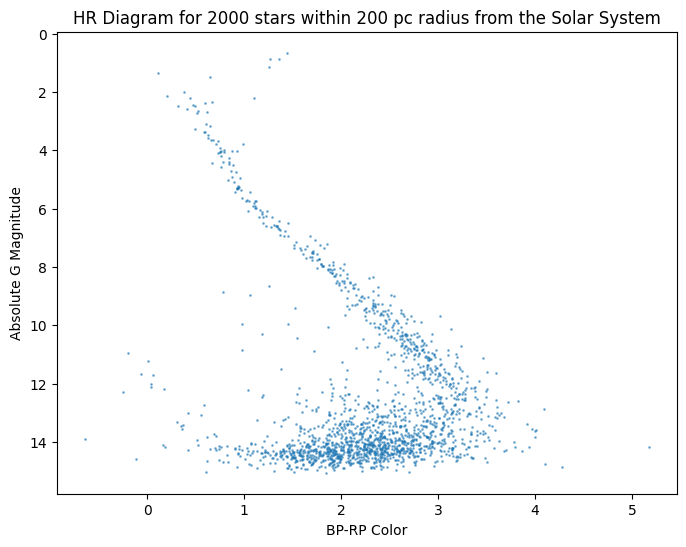

In [15]:
# plot the H-R diagram for the 2000 stars within 200 pc radius from the Solar System
%matplotlib inline
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(bp_rp, abs_mag, s=1, alpha=0.5)
plt.gca().invert_yaxis()
plt.xlabel("BP-RP Color")
plt.ylabel("Absolute G Magnitude")
plt.title(f"HR Diagram for 2000 stars within 200 pc radius from the Solar System")
plt.show()

In [16]:
# Here I am defining a python function to execute a asynchronous query which I can then pass to a Job
def send_radial_gaia_query(query_size=500, distance=200, **kwargs):
    """
    Sends an archive query for d < 200 pc, with additional filters taken from
    Gaia Data Release 3: Observational Hertzsprung-Russell diagrams (Sect. 2.1)
    Gaia Collaboration, Babusiaux et al. (2018)
    (https://doi.org/10.1051/0004-6361/201832843)

    NOTE: 10000000 is a maximum query size (~76 MB / column)

    Additional keyword arguments are passed to Gaia.launch_job_async method.
    """
    query3 = (" SELECT"
            " TOP {}".format(query_size)+
            " source_id, ra, dec, parallax, bp_rp, phot_g_mean_mag+5*log10(parallax)-10 as mg, 1000/parallax as dist"
            " FROM gaiadr3.gaia_source"
            " WHERE parallax > 0"
            " AND bp_rp > -0.75"
            " AND bp_rp < 6"
            " AND 1000/parallax <= {}".format(distance)+
            " AND bp_rp > -0.75"
            " AND bp_rp < 6"
            " AND visibility_periods_used > 8"
            " AND phot_g_mean_flux_over_error > 50"
            " AND phot_bp_mean_flux_over_error > 20"
            " AND phot_rp_mean_flux_over_error > 20"  
            " and phot_bp_rp_excess_factor <"
            " 1.3+0.06*power(phot_bp_mean_mag-phot_rp_mean_mag,2)"
            " and phot_bp_rp_excess_factor >"
            " 1.0+0.015*power(phot_bp_mean_mag-phot_rp_mean_mag,2)"
            " and astrometric_chi2_al/(astrometric_n_good_obs_al-5)<"
            "1.44*greatest(1,exp(-0.4*(phot_g_mean_mag-19.5)))"   
    )


    
    job = Gaia.launch_job_async(query3, **kwargs)
    return job

In [17]:
job3 = send_radial_gaia_query(query_size=10000,distance=200)  # Query 10000 alhough default is 500 stars
results = job3.get_results()
results

INFO: Query finished. [astroquery.utils.tap.core]


SOURCE_ID,ra,dec,parallax,bp_rp,mg,dist
,deg,deg,mas,mag,,
int64,float64,float64,float64,float32,float64,float64
6138939319025133568,193.63671923006,-42.41140586914759,5.012721582768959,0.52110577,2.494899549682625,199.4924281127965
518776906275823360,29.503171842622802,65.9909748464152,5.382121129976117,2.673298,11.018002812462534,185.80035191523783
3161067754872741248,106.52226074750766,12.833358296506074,5.683503106574727,-0.22271156,11.625915210107877,175.94782324358917
3161067862249679104,106.52274738580583,12.863043762228125,10.359002306980344,1.2902861,5.957648341871071,96.53439302027732
3160008895111322368,109.00502624174776,11.881365980990305,5.4433089850250065,2.4480324,10.042970027288217,183.71178317289773
3159042183874320896,103.81464634726414,10.762822840415703,7.283272566001613,2.854599,10.720123950167647,137.30091671538008
5883300460403640576,231.79005548105067,-56.5507382805257,5.244799520391638,2.8542366,9.778747762884656,190.6650570936081
5883300460403641472,231.79200277942138,-56.54956222846867,5.433870597856739,2.7604904,10.00614529077832,184.03088222130762


In [18]:
mg = results["mg"]
bp_rp = results["bp_rp"]

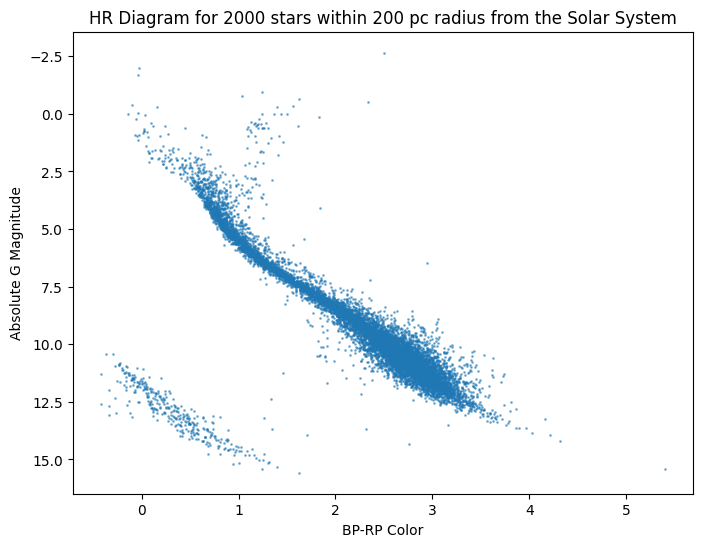

In [19]:
# plot the H-R diagram for the 2000 stars within 200 pc radius from the Solar System
%matplotlib inline
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(bp_rp, mg, s=1, alpha=0.5)
plt.gca().invert_yaxis()
plt.xlabel("BP-RP Color")
plt.ylabel("Absolute G Magnitude")
plt.title(f"HR Diagram for 2000 stars within 200 pc radius from the Solar System")
plt.show()

In [20]:
# sun's HRD coordinates values for plotting
#     google "what is bp-rp of the sun" bp-rp = 0.82
bp_rp_sun = 0.82

#     we calculated the abs mag of the sun in the "brightness of stars" project
#     we will do it again below:
sun_app_mag = -27 # very very bright in the sky!
sun_dist_km = 150e6 #km
light_speed = 3e5 #km/s
seconds_in_a_year = 365*24*60*60
light_year_km =  seconds_in_a_year * light_speed
parsec_km = light_year_km * 3.26 #km/pc
sun_dist_pc = sun_dist_km / parsec_km

# Use the magnitude formula above to calculate the absolute magnitude of the Sun
sun_abs_mag = sun_app_mag - 5 * np.log10(sun_dist_pc) + 5
#print(sun_abs_mag)

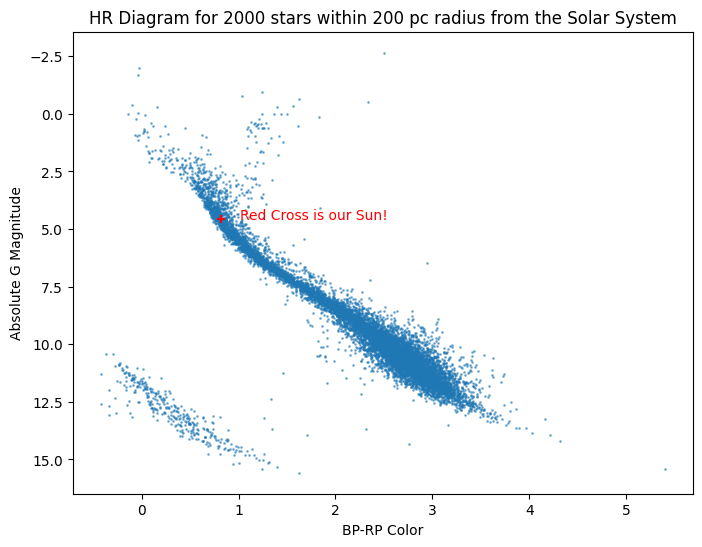

In [21]:
# plot the H-R diagram for the 2000 stars within 200 pc radius from the Solar System
# Also plot the Sun!
%matplotlib inline
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(bp_rp, mg, s=1, alpha=0.5)

plt.scatter(bp_rp_sun, sun_abs_mag, marker='+', color="red") # plot sun
plt.text(bp_rp_sun+0.2, sun_abs_mag, "Red Cross is our Sun!",  color="red")

plt.gca().invert_yaxis()
plt.xlabel("BP-RP Color")
plt.ylabel("Absolute G Magnitude")
plt.title(f"HR Diagram for 2000 stars within 200 pc radius from the Solar System")
plt.show()

In [22]:
!ls -l data_folder

total 13468
drwxr-xr-x 3 jupyter-chandru.narayan.p4-55c04 jupyter-chandru.narayan.p4-55c04     4096 Feb 12 02:13 archive
drwxr-xr-x 2 jupyter-chandru.narayan.p4-55c04 jupyter-chandru.narayan.p4-55c04     4096 Feb 12 02:11 archive2
-rw-r--r-- 1 jupyter-chandru.narayan.p4-55c04 jupyter-chandru.narayan.p4-55c04 12212359 Feb 12 03:48 gaia-hrd-dr3-200pc_100000_stars.csv
-rw-r--r-- 1 jupyter-chandru.narayan.p4-55c04 jupyter-chandru.narayan.p4-55c04  1222720 Feb 12 03:35 gaia-hrd-dr3-200pc_10000_stars.csv
-rw-r--r-- 1 jupyter-chandru.narayan.p4-55c04 jupyter-chandru.narayan.p4-55c04   342688 Feb 12 03:59 gaia-hrd-dr3-200pc_10000_stars.csv.png


In [23]:
# Here I am defining a job for the same asynchronous within a try-except block
# This will first look for a previoysly stored file (try-block)
# if it does not exist it will execute the query (except-bloclk)

import numpy as np
from astropy import log

num_stars = 10000
small_datafile_name = data_folder+"/gaia-hrd-dr3-200pc_%d_stars.csv" % (num_stars)
try:
    log.info(f"Getting the DR3 results on nearby (d < 200 pc) stars stored in {small_datafile_name}\n")
    #gaiarec = np.recfromcsv(small_datafile_name)
    gaiarec = np.genfromtxt(small_datafile_name, delimiter=',', names=True, dtype=None)
    #bp_rp, mg, dist = gaiarec.bp_rp, gaiarec.mg, gaiarec.dist
    bp_rp, mg, dist = gaiarec["bp_rp"], gaiarec["mg"], gaiarec["dist"]
    print(f"reading OLD results from previously existng {small_datafile_name}\n")
    print(bp_rp, mg, dist)
except OSError:
    job4 = send_radial_gaia_query(dump_to_file=True, output_format="csv",
                                 output_file=small_datafile_name,
                                 query_size=num_stars,distance=200)
    results = job4.get_results()
    bp_rp = results['bp_rp'].data
    mg = results['mg'].data
    dist = results['dist'].data
    print(f"querying and saving NEW results to {small_datafile_name}\n")
    print(bp_rp, mg, dist)


INFO: Getting the DR3 results on nearby (d < 200 pc) stars stored in data_folder/gaia-hrd-dr3-200pc_10000_stars.csv
 [unknown]
reading OLD results from previously existng data_folder/gaia-hrd-dr3-200pc_10000_stars.csv

[1.1410713 2.317212  2.4880295 ... 2.3791409 1.0815678 2.6637983] [6.45323666 9.09605768 9.59247812 ... 9.11706057 5.74137319 9.96604035] [159.6835633  196.85090883 138.92421473 ... 193.41980877 143.53549715
 120.23910969]


In [24]:
!ls -ltr {data_folder}
data_folder        

total 13468
drwxr-xr-x 2 jupyter-chandru.narayan.p4-55c04 jupyter-chandru.narayan.p4-55c04     4096 Feb 12 02:11 archive2
drwxr-xr-x 3 jupyter-chandru.narayan.p4-55c04 jupyter-chandru.narayan.p4-55c04     4096 Feb 12 02:13 archive
-rw-r--r-- 1 jupyter-chandru.narayan.p4-55c04 jupyter-chandru.narayan.p4-55c04  1222720 Feb 12 03:35 gaia-hrd-dr3-200pc_10000_stars.csv
-rw-r--r-- 1 jupyter-chandru.narayan.p4-55c04 jupyter-chandru.narayan.p4-55c04 12212359 Feb 12 03:48 gaia-hrd-dr3-200pc_100000_stars.csv
-rw-r--r-- 1 jupyter-chandru.narayan.p4-55c04 jupyter-chandru.narayan.p4-55c04   342688 Feb 12 03:59 gaia-hrd-dr3-200pc_10000_stars.csv.png


'data_folder'

#### Find the CSV file and double-click it!
#### Once you have done this - go back to the previous Cell and execute once more and see what happens!!
#### Can you describe what happened ??
#### Now let's plot it!!

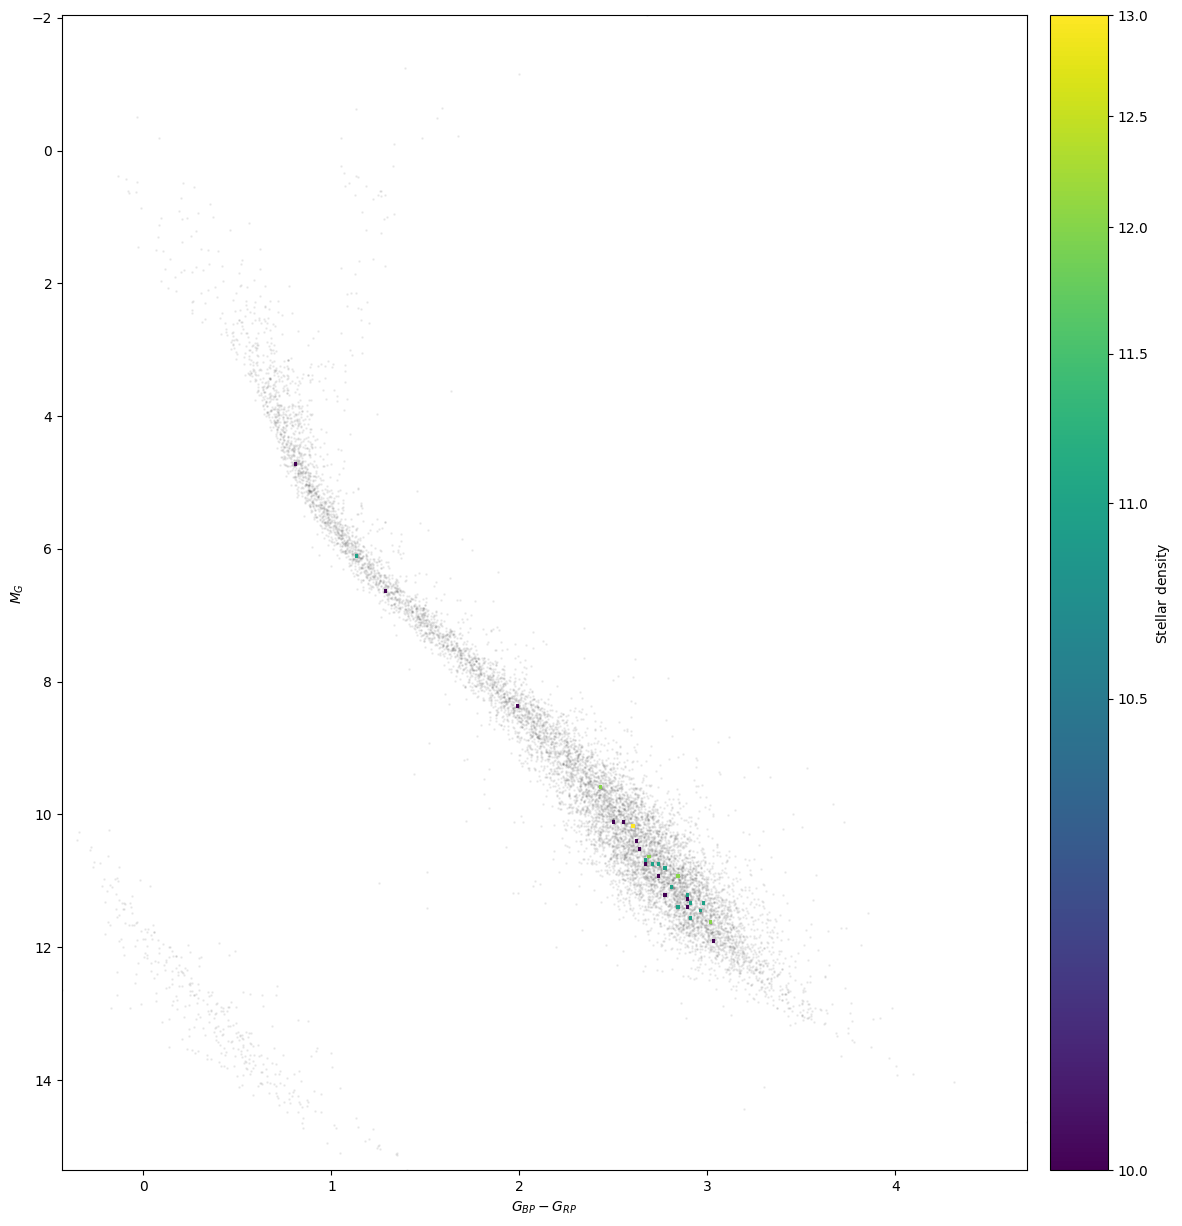

In [25]:
# plot the H-R diagram for the 10000 stars within 200 pc from the Sun
%matplotlib inline
import matplotlib.pyplot as plt
from matplotlib import colors
plt.rc('text', usetex=False)

fig, ax = plt.subplots(figsize=(15, 15))
# only show 2D-histogram for bins with more than 10 stars in them
h = ax.hist2d(bp_rp, mg, bins=300, cmin=10, norm=colors.PowerNorm(0.5), zorder=0.5)
# fill the rest with scatter (set rasterized=True if saving as vector graphics)
ax.scatter(bp_rp, mg, alpha=0.05, s=1, color='k', zorder=0)
ax.invert_yaxis()
cb = fig.colorbar(h[3], ax=ax, pad=0.02)
ax.set_xlabel(r'$G_{BP} - G_{RP}$')
ax.set_ylabel(r'$M_G$')
cb.set_label(r"$\mathrm{Stellar~density}$")
plt.savefig(f"{small_datafile_name}.png", dpi=140)

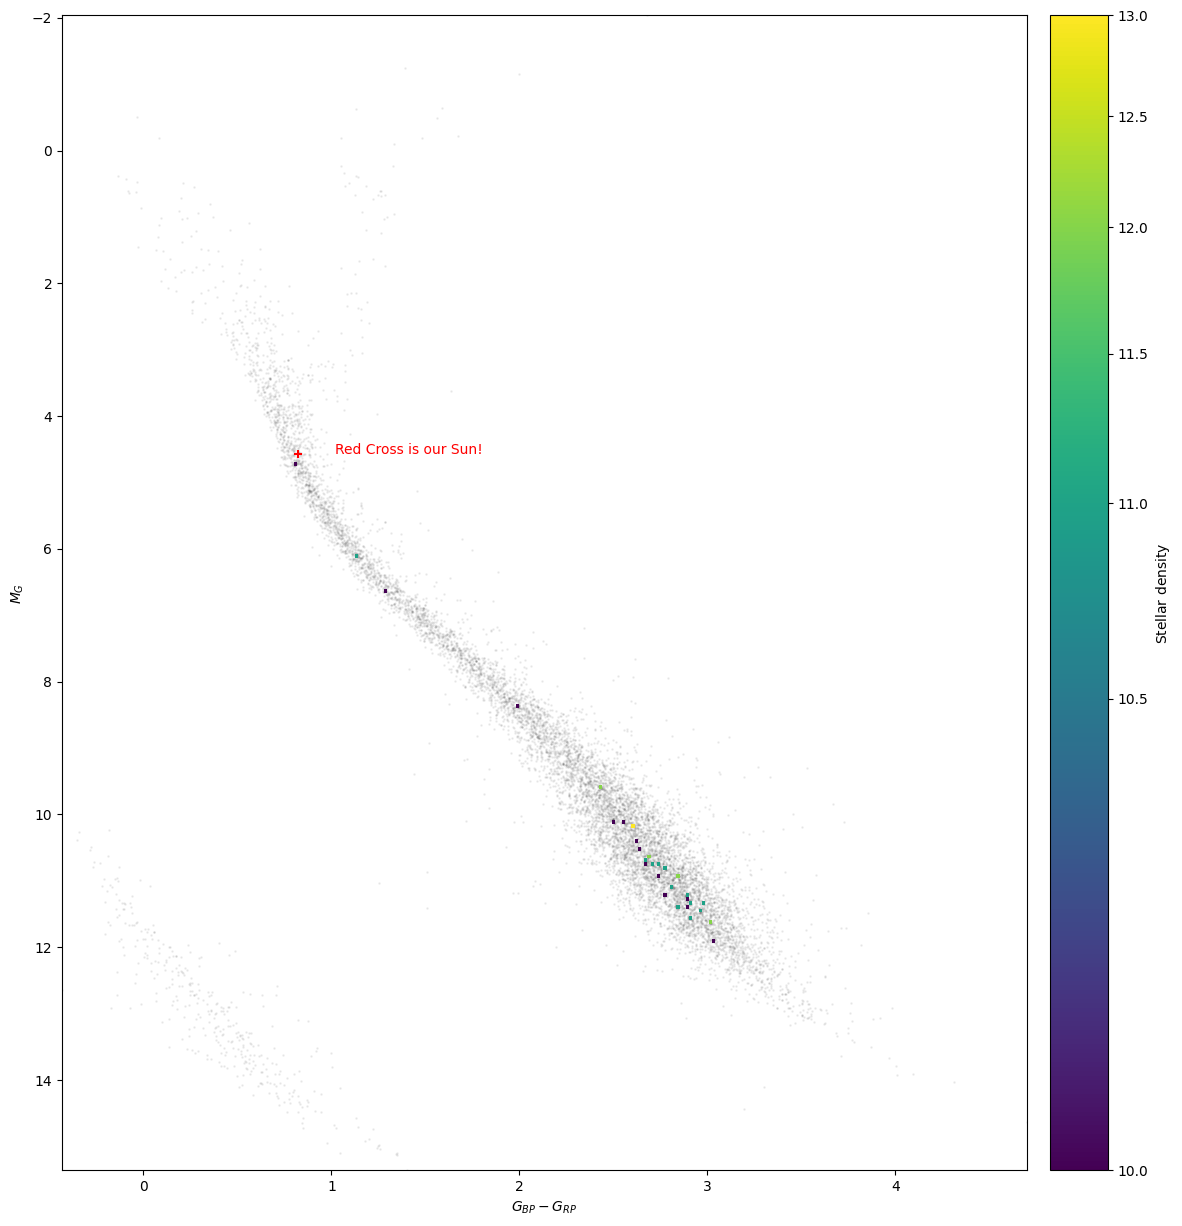

In [26]:
# plot the H-R diagram for the 10000 stars within 200 pc from the Sun
%matplotlib inline
import matplotlib.pyplot as plt
from matplotlib import colors
plt.rc('text', usetex=False)

fig, ax = plt.subplots(figsize=(15, 15))
# only show 2D-histogram for bins with more than 10 stars in them
h = ax.hist2d(bp_rp, mg, bins=300, cmin=10, norm=colors.PowerNorm(0.5), zorder=0.5)
# fill the rest with scatter (set rasterized=True if saving as vector graphics)
ax.scatter(bp_rp, mg, alpha=0.05, s=1, color='k', zorder=0)

ax.scatter(bp_rp_sun, sun_abs_mag, marker='+', color="red") # plot sun
plt.text(bp_rp_sun+0.2, sun_abs_mag, "Red Cross is our Sun!",  color="red")

ax.invert_yaxis()
cb = fig.colorbar(h[3], ax=ax, pad=0.02)
ax.set_xlabel(r'$G_{BP} - G_{RP}$')
ax.set_ylabel(r'$M_G$')
cb.set_label(r"$\mathrm{Stellar~density}$")
plt.savefig(f"{small_datafile_name}.png", dpi=140)

In [27]:
# Here I am defining a new with filters job for the same asynchronous within the try-except block
# This time for 100000 stars now including the filters
# This will first look for a reviosly stored file (try-block)
# if it does not exist it will execute the query (except-block)
import numpy as np
from astropy import log

# the query runs for a while, better ensure we have those data saved
num_stars = 100000
large_datafile_name = data_folder+"/gaia-hrd-dr3-200pc_%d_stars.csv" % (num_stars)
try:
    log.info(f"Getting the DR3 results on nearby (d < 200 pc) stars stored in {large_datafile_name}\n")
    #gaiarec = np.recfromcsv(large_datafile_name)
    gaiarec = np.genfromtxt(large_datafile_name, delimiter=',', names=True, dtype=None)
    #bp_rp, mg, dist = gaiarec.bp_rp, gaiarec.mg, gaiarec.dist
    bp_rp, mg, dist = gaiarec["bp_rp"], gaiarec["mg"], gaiarec["dist"]
    print(f"reading OLD results from previously existng {large_datafile_name}\n")
    print(bp_rp, mg, dist)    
except OSError:
    job = send_radial_gaia_query(dump_to_file=True, output_format="csv"
                                 ,output_file=large_datafile_name
                                 ,query_size=num_stars
    )
    r = job.get_results()
    bp_rp = r['bp_rp'].data
    mg = r['mg'].data
    dist = r['dist'].data
    print(f"querying and saving NEW results to {large_datafile_name}\n")
    print(bp_rp, mg, dist)

INFO: Getting the DR3 results on nearby (d < 200 pc) stars stored in data_folder/gaia-hrd-dr3-200pc_100000_stars.csv
 [unknown]
reading OLD results from previously existng data_folder/gaia-hrd-dr3-200pc_100000_stars.csv

[2.6637983 1.0324898 2.872158  ... 2.6759615 1.9603071 1.8937731] [ 9.96604035  5.80066951 11.01787851 ...  9.41142694  8.77314012
  8.13277929] [120.23910969 156.97454485 111.49180129 ... 139.54885977 119.76518188
 113.63412484]


In [28]:
!ls -ltr {data_folder}

total 13348
drwxr-xr-x 2 jupyter-chandru.narayan.p4-55c04 jupyter-chandru.narayan.p4-55c04     4096 Feb 12 02:11 archive2
drwxr-xr-x 3 jupyter-chandru.narayan.p4-55c04 jupyter-chandru.narayan.p4-55c04     4096 Feb 12 02:13 archive
-rw-r--r-- 1 jupyter-chandru.narayan.p4-55c04 jupyter-chandru.narayan.p4-55c04  1222720 Feb 12 03:35 gaia-hrd-dr3-200pc_10000_stars.csv
-rw-r--r-- 1 jupyter-chandru.narayan.p4-55c04 jupyter-chandru.narayan.p4-55c04 12212359 Feb 12 03:48 gaia-hrd-dr3-200pc_100000_stars.csv
-rw-r--r-- 1 jupyter-chandru.narayan.p4-55c04 jupyter-chandru.narayan.p4-55c04   218036 Feb 12 04:03 gaia-hrd-dr3-200pc_10000_stars.csv.png


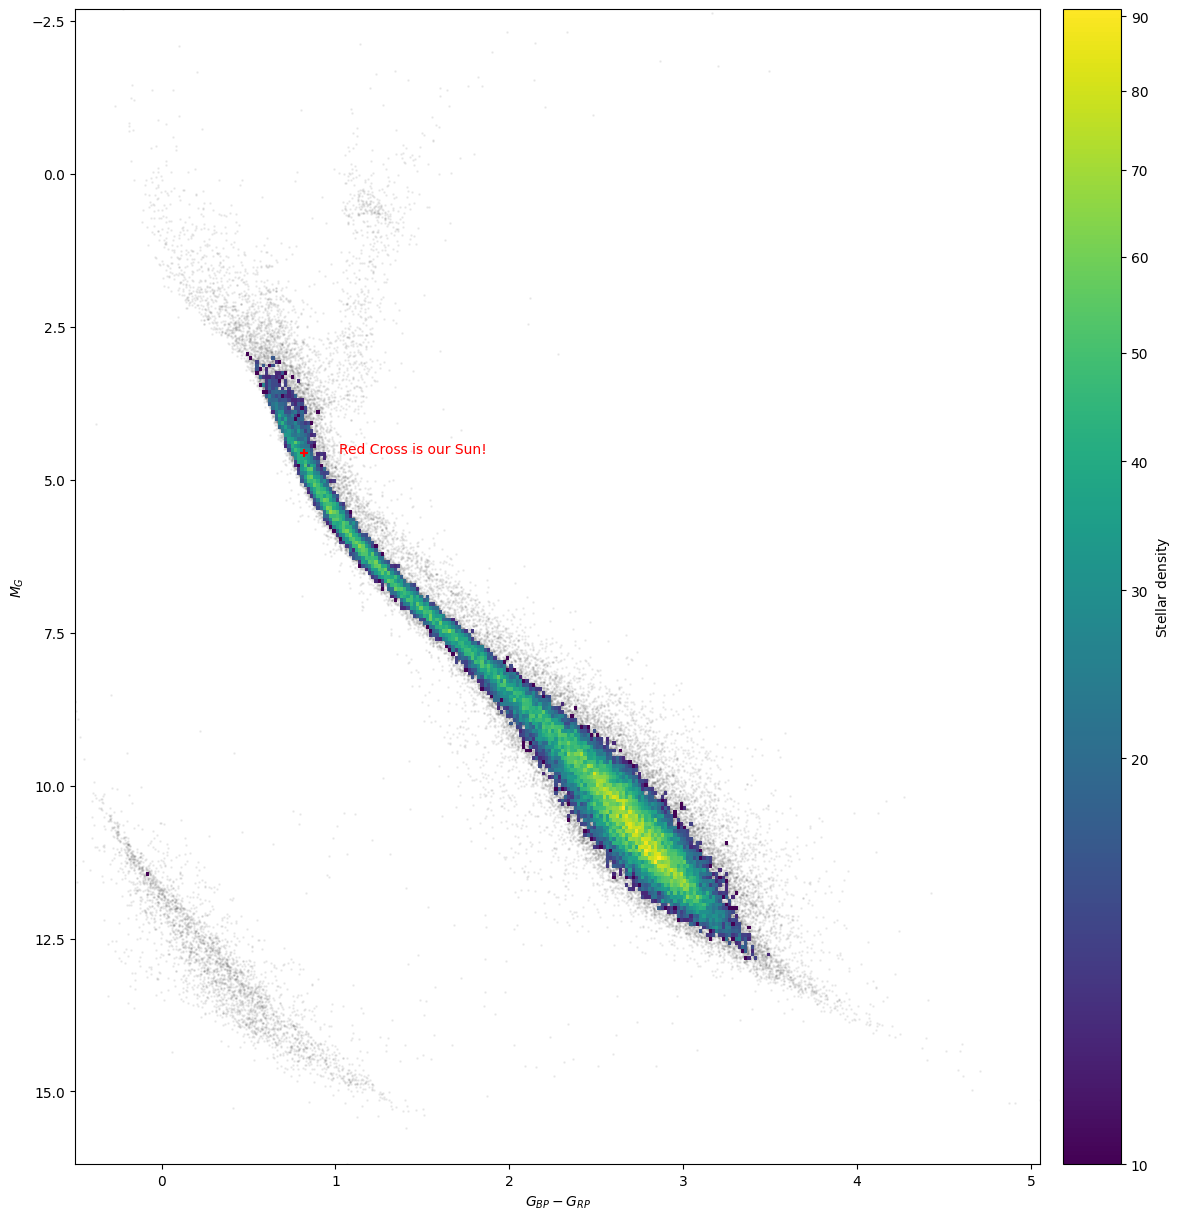

In [29]:
# plot the H-R diagram for the 10000 stars within 200 pc from the Sun
%matplotlib inline
import matplotlib.pyplot as plt
from matplotlib import colors
plt.rc('text', usetex=False)

fig, ax = plt.subplots(figsize=(15, 15))
# only show 2D-histogram for bins with more than 10 stars in them
h = ax.hist2d(bp_rp, mg, bins=300, cmin=10, norm=colors.PowerNorm(0.5), zorder=0.5)
# fill the rest with scatter (set rasterized=True if saving as vector graphics)
ax.scatter(bp_rp, mg, alpha=0.05, s=1, color='k', zorder=0)

ax.scatter(bp_rp_sun, sun_abs_mag, marker='+', color="red") # plot sun
plt.text(bp_rp_sun+0.2, sun_abs_mag, "Red Cross is our Sun!",  color="red")

ax.invert_yaxis()
cb = fig.colorbar(h[3], ax=ax, pad=0.02)
ax.set_xlabel(r'$G_{BP} - G_{RP}$')
ax.set_ylabel(r'$M_G$')
cb.set_label(r"$\mathrm{Stellar~density}$")
plt.savefig(f"{small_datafile_name}.png", dpi=140)

In [31]:
cquery = ("SELECT *, DISTANCE(302.95, -43.98, l, b) AS ang_sep"
        " FROM gaiadr3.gaia_source"
        " WHERE DISTANCE(302.95, -43.98, l, b) < 5./60."
        " AND has_epoch_photometry = 'True'"
        " AND has_xp_continuous = 'True'")

In [32]:
def send_custom_gaia_query(cust_query, **kwargs):
    """
    Sends an archive query for d < 200 pc, with additional filters taken from
    Gaia Data Release 3: Observational Hertzsprung-Russell diagrams (Sect. 2.1)
    Gaia Collaboration, Babusiaux et al. (2018)
    (https://doi.org/10.1051/0004-6361/201832843)

    NOTE: 10000000 is a maximum query size (~76 MB / column)

    Additional keyword arguments are passed to Gaia.launch_job_async method.
    """
    
    job = Gaia.launch_job_async(cust_query, **kwargs)
    return job

In [34]:
job4 = send_custom_gaia_query(cquery)  # Query 10000 alhough default is 500 stars
results = job4.get_results()
results

INFO: Query finished. [astroquery.utils.tap.core]


solution_id,DESIGNATION,SOURCE_ID,random_index,ref_epoch,ra,ra_error,dec,dec_error,parallax,parallax_error,parallax_over_error,pm,pmra,pmra_error,pmdec,pmdec_error,ra_dec_corr,ra_parallax_corr,ra_pmra_corr,ra_pmdec_corr,dec_parallax_corr,dec_pmra_corr,dec_pmdec_corr,parallax_pmra_corr,parallax_pmdec_corr,pmra_pmdec_corr,astrometric_n_obs_al,astrometric_n_obs_ac,astrometric_n_good_obs_al,astrometric_n_bad_obs_al,astrometric_gof_al,astrometric_chi2_al,astrometric_excess_noise,astrometric_excess_noise_sig,astrometric_params_solved,astrometric_primary_flag,nu_eff_used_in_astrometry,pseudocolour,pseudocolour_error,ra_pseudocolour_corr,dec_pseudocolour_corr,parallax_pseudocolour_corr,pmra_pseudocolour_corr,pmdec_pseudocolour_corr,astrometric_matched_transits,visibility_periods_used,astrometric_sigma5d_max,matched_transits,new_matched_transits,matched_transits_removed,ipd_gof_harmonic_amplitude,ipd_gof_harmonic_phase,ipd_frac_multi_peak,ipd_frac_odd_win,ruwe,scan_direction_strength_k1,scan_direction_strength_k2,scan_direction_strength_k3,scan_direction_strength_k4,scan_direction_mean_k1,scan_direction_mean_k2,scan_direction_mean_k3,scan_direction_mean_k4,duplicated_source,phot_g_n_obs,phot_g_mean_flux,phot_g_mean_flux_error,phot_g_mean_flux_over_error,phot_g_mean_mag,phot_bp_n_obs,phot_bp_mean_flux,phot_bp_mean_flux_error,phot_bp_mean_flux_over_error,phot_bp_mean_mag,phot_rp_n_obs,phot_rp_mean_flux,phot_rp_mean_flux_error,phot_rp_mean_flux_over_error,phot_rp_mean_mag,phot_bp_rp_excess_factor,phot_bp_n_contaminated_transits,phot_bp_n_blended_transits,phot_rp_n_contaminated_transits,phot_rp_n_blended_transits,phot_proc_mode,bp_rp,bp_g,g_rp,radial_velocity,radial_velocity_error,rv_method_used,rv_nb_transits,rv_nb_deblended_transits,rv_visibility_periods_used,rv_expected_sig_to_noise,rv_renormalised_gof,rv_chisq_pvalue,rv_time_duration,rv_amplitude_robust,rv_template_teff,rv_template_logg,rv_template_fe_h,rv_atm_param_origin,vbroad,vbroad_error,vbroad_nb_transits,grvs_mag,grvs_mag_error,grvs_mag_nb_transits,rvs_spec_sig_to_noise,phot_variable_flag,l,b,ecl_lon,ecl_lat,in_qso_candidates,in_galaxy_candidates,non_single_star,has_xp_continuous,has_xp_sampled,has_rvs,has_epoch_photometry,has_epoch_rv,has_mcmc_gspphot,has_mcmc_msc,in_andromeda_survey,classprob_dsc_combmod_quasar,classprob_dsc_combmod_galaxy,classprob_dsc_combmod_star,teff_gspphot,teff_gspphot_lower,teff_gspphot_upper,logg_gspphot,logg_gspphot_lower,logg_gspphot_upper,mh_gspphot,mh_gspphot_lower,mh_gspphot_upper,distance_gspphot,distance_gspphot_lower,distance_gspphot_upper,azero_gspphot,azero_gspphot_lower,azero_gspphot_upper,ag_gspphot,ag_gspphot_lower,ag_gspphot_upper,ebpminrp_gspphot,ebpminrp_gspphot_lower,ebpminrp_gspphot_upper,libname_gspphot,ang_sep
,,,,yr,deg,mas,deg,mas,mas,mas,,mas / yr,mas / yr,mas / yr,mas / yr,mas / yr,,,,,,,,,,,,,,,,,mas,,,,1 / um,1 / um,1 / um,,,,,,,,mas,,,,,deg,,,,,,,,deg,deg,deg,deg,,,electron / s,electron / s,,mag,,electron / s,electron / s,,mag,,electron / s,electron / s,,mag,,,,,,,mag,mag,mag,km / s,km / s,,,,,,,,d,km / s,K,log(cm.s**-2),dex,,km / s,km / s,,mag,mag,,,,deg,deg,deg,deg,,,,,,,,,,,,,,,K,K,K,log(cm.s**-2),log(cm.s**-2),log(cm.s**-2),dex,dex,dex,pc,pc,pc,mag,mag,mag,mag,mag,mag,mag,mag,mag,,
int64,object,int64,int64,float64,float64,float32,float64,float32,float64,float32,float32,float32,float64,float32,float64,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int16,int16,int16,int16,float32,float32,float32,float32,int16,bool,float32,float32,float32,float32,float32,float32,float32,float32,int16,int16,float32,int16,int16,int16,float32,float32,int16,int16,float32,float32,float32,float32,float32,float32,float32,float32,float32,bool,int16,float64,float32,float32,float32,int16,float64,float32,float32,float32,int16,float64,float32,float32,float32,float32,int16,int16,int16,int16,int16,float32,float32,float32,float32,float32,int16,int16,int16,int16,float32,float32,float32,float32,float32,float32,float32

In [18]:
mg = results["mg"]
bp_rp = results["bp_rp"]

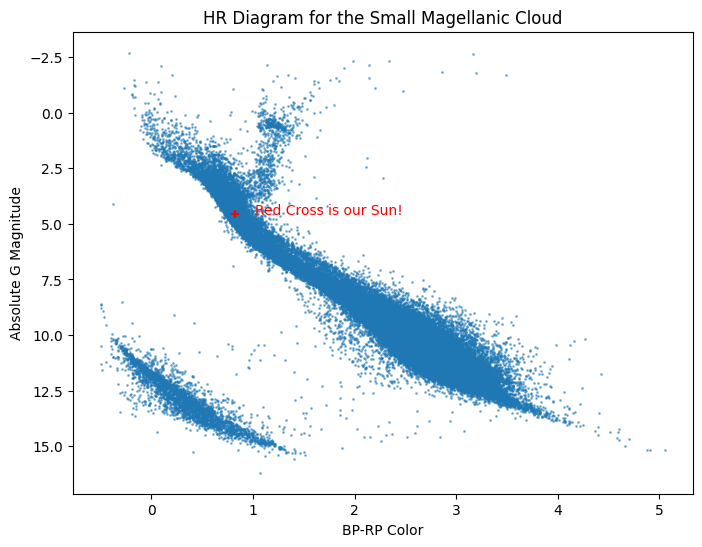

In [36]:
# plot the H-R diagram for stars in the Small Magellanic Cloud
%matplotlib inline
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(bp_rp, mg, s=1, alpha=0.5)

plt.scatter(bp_rp_sun, sun_abs_mag, marker='+', color="red") # plot sun
plt.text(bp_rp_sun+0.2, sun_abs_mag, "Red Cross is our Sun!",  color="red")

plt.gca().invert_yaxis()
plt.xlabel("BP-RP Color")
plt.ylabel("Absolute G Magnitude")
plt.title(f"HR Diagram for the Small Magellanic Cloud")
plt.show()